In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.ensemble import(RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import r2_score
import pickle 
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('gld_price_data.csv')

In [4]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
df.describe ()


,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [6]:
df.sample(10)

,Date,SPX,GLD,USO,SLV,EUR/USD
1111,1/24/2013,1494.819946,161.419998,34.759998,30.650000,1.330849
1937,10/20/2016,2141.340088,120.739998,11.430000,16.639999,1.093040
703,3/14/2011,1296.390015,138.860001,40.910000,35.009998,1.393456
735,5/4/2011,1347.319946,147.729996,43.259998,38.270000,1.482975
1086,12/17/2012,1430.359985,164.440002,32.009998,31.200001,1.316586
389,10/29/2009,1066.109985,102.690002,40.900002,16.410000,1.484010
1764,1/4/2016,2012.660034,102.889999,10.980000,13.190000,1.085399
481,3/15/2010,1150.510010,108.360001,38.830002,16.740000,1.367746
291,5/7/2009,907.390015,89.440002,31.490000,13.600000,1.363903
2212,1/16/2018,2776.419922,127.169998,12.760000,16.250000,1.226843


In [7]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Quarter'] = df['Date'].dt.quarter

In [12]:
df.corr(numeric_only= True)['GLD']

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Year       0.206654
Month      0.020494
Day       -0.000198
Quarter    0.018193
Name: GLD, dtype: float64

In [13]:
correlation = df.corr(numeric_only = True)

<Axes: xlabel='GLD'>

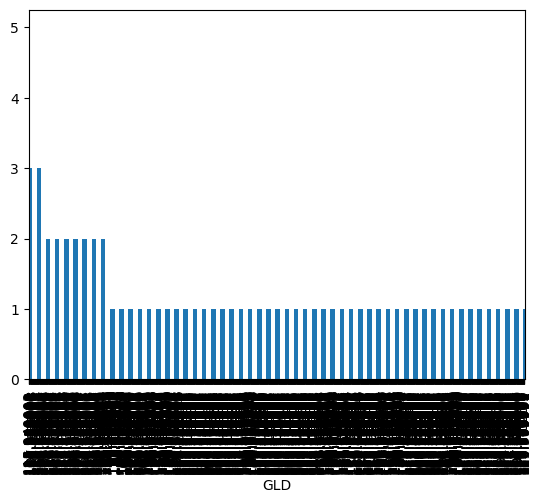

In [14]:
df['GLD'].value_counts().plot(kind = 'bar')

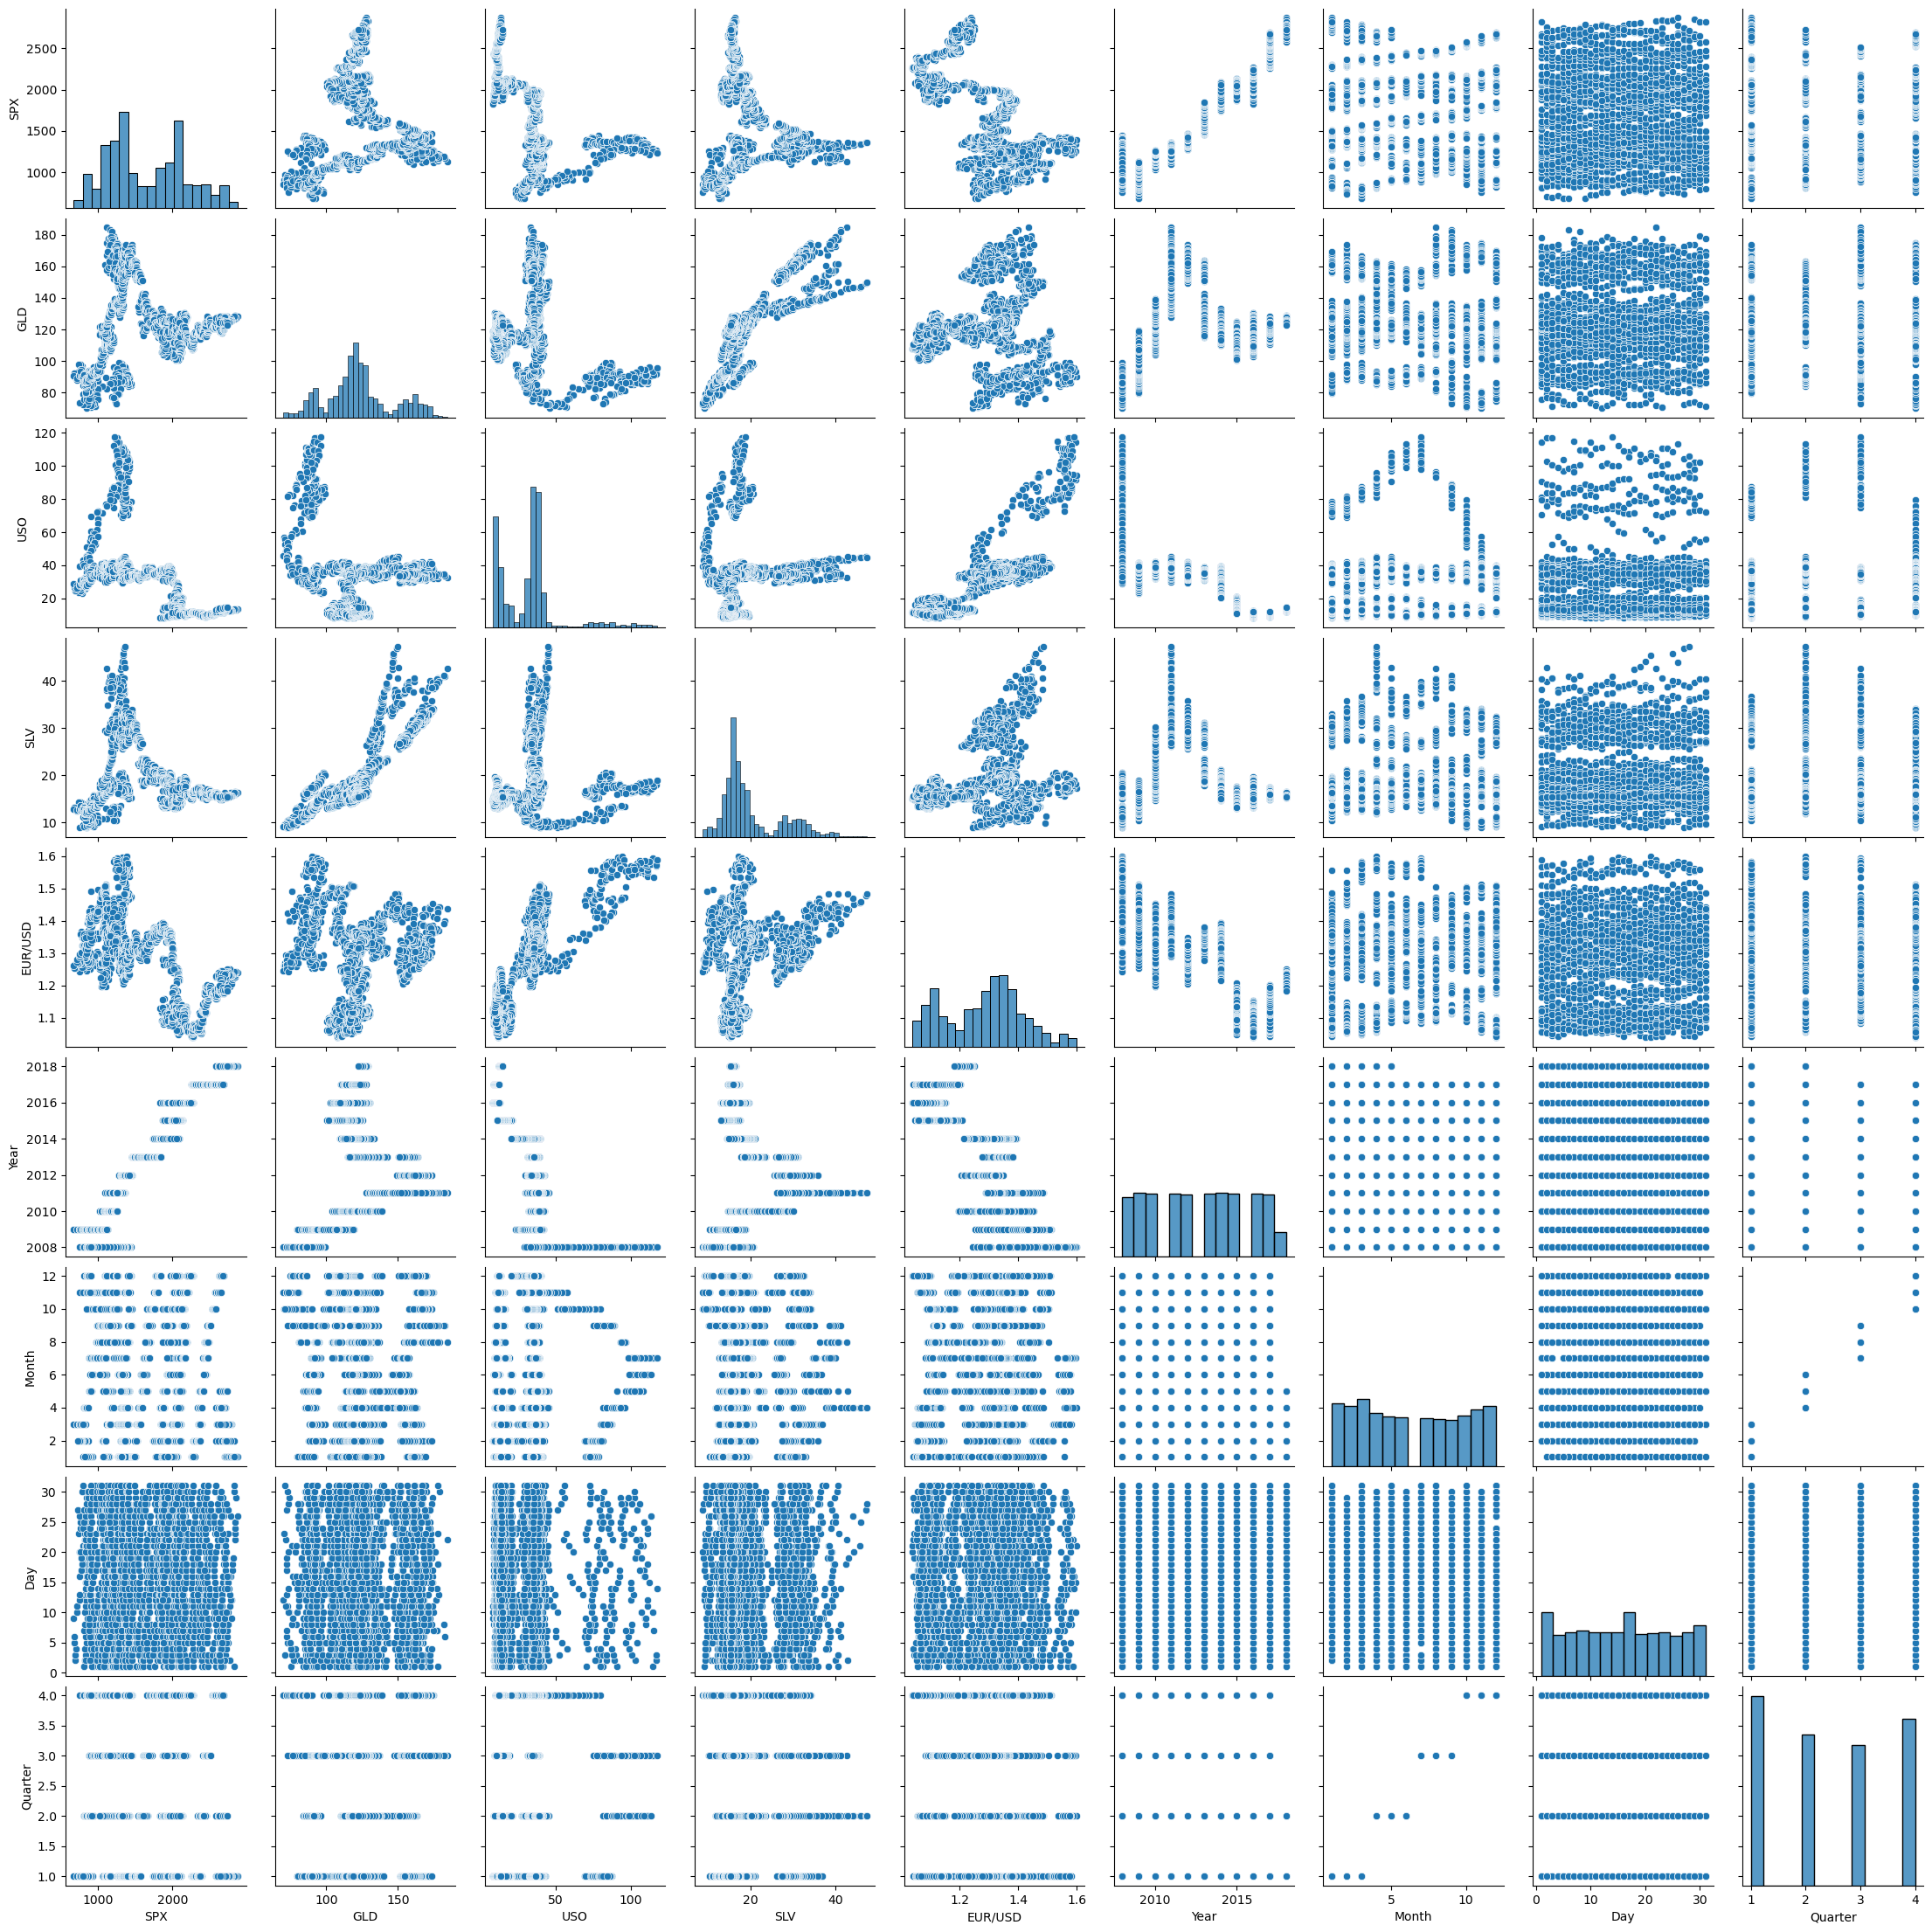

In [15]:
sns.pairplot(df )

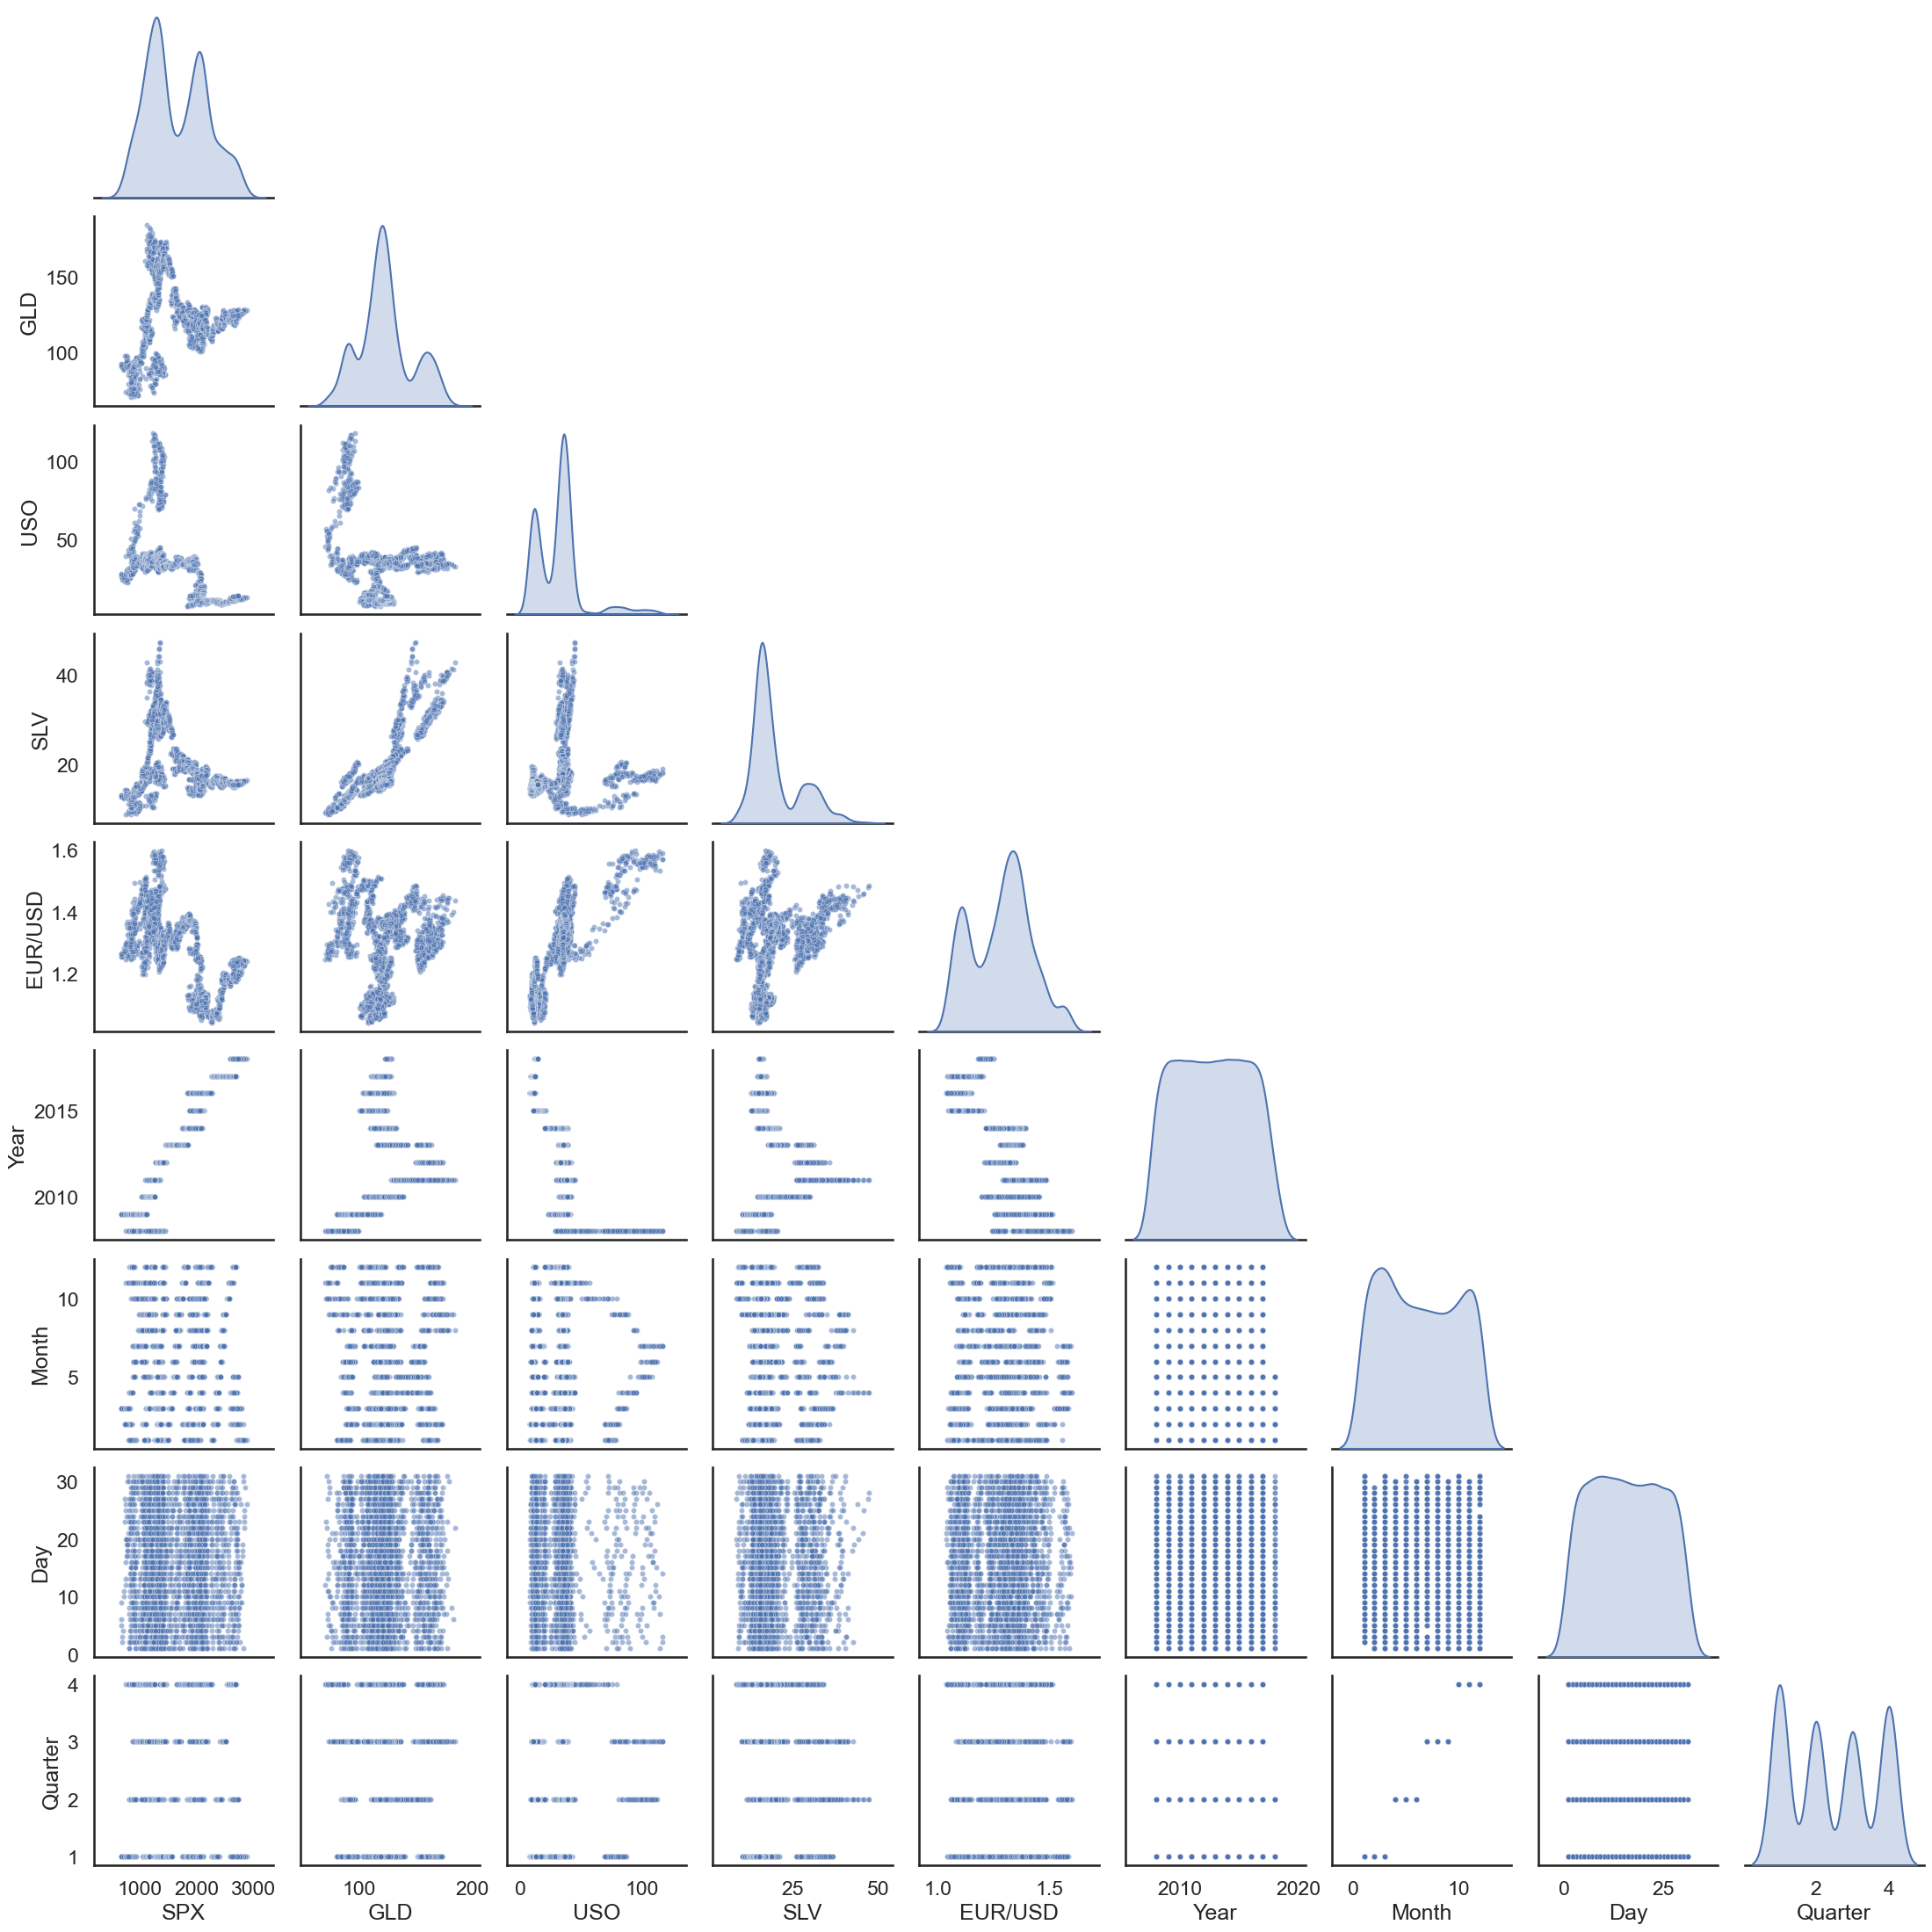

In [16]:
sns.set_theme(style="white", context="talk")

sns.pairplot(
    df,
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha':0.5, 's':20}
)

In [17]:
df.pivot_table(values = 'SPX',index='Date',columns = 'EUR/USD')

EUR/USD,1.039047,1.040583,1.041699,1.041884,1.041992,1.042862,1.043765,1.044998,1.045697,1.046003,...,1.582404,1.585389,1.585590,1.587402,1.587806,1.589901,1.590204,1.594896,1.595813,1.598798
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-05-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print(df['GLD'].unique())
print(df['EUR/USD'].dtype)

print(df[df['GLD'] == 0]['EUR/USD'].shape)
print(df[df['GLD'] == 1]['EUR/USD'].shape)

print(df[df['GLD'] == 0]['EUR/USD'].head())
print(df[df['GLD'] == 1]['EUR/USD'].head())

[ 84.860001  85.57      85.129997 ... 124.330002 124.489998 122.5438  ]
float64
(0,)
(0,)
Series([], Name: EUR/USD, dtype: float64)
Series([], Name: EUR/USD, dtype: float64)


<Axes: xlabel='GLD', ylabel='SPX'>

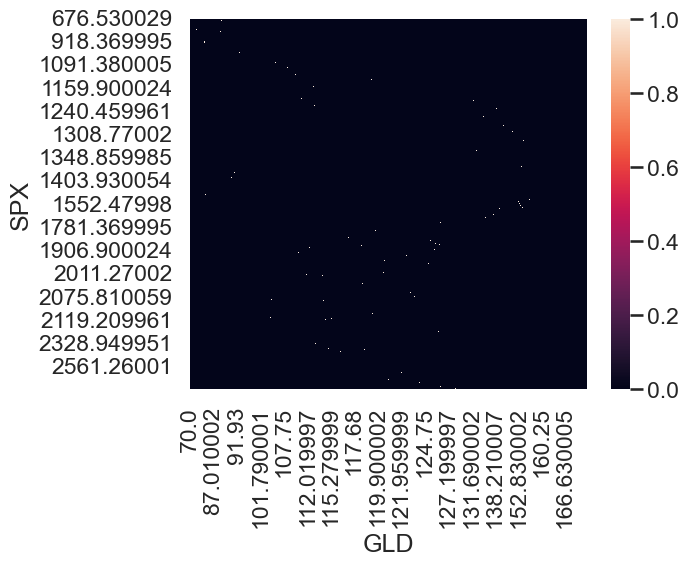

In [19]:
sns.heatmap(pd.crosstab(df['SPX'],df['GLD']))

<Axes: xlabel='EUR/USD', ylabel='Date'>

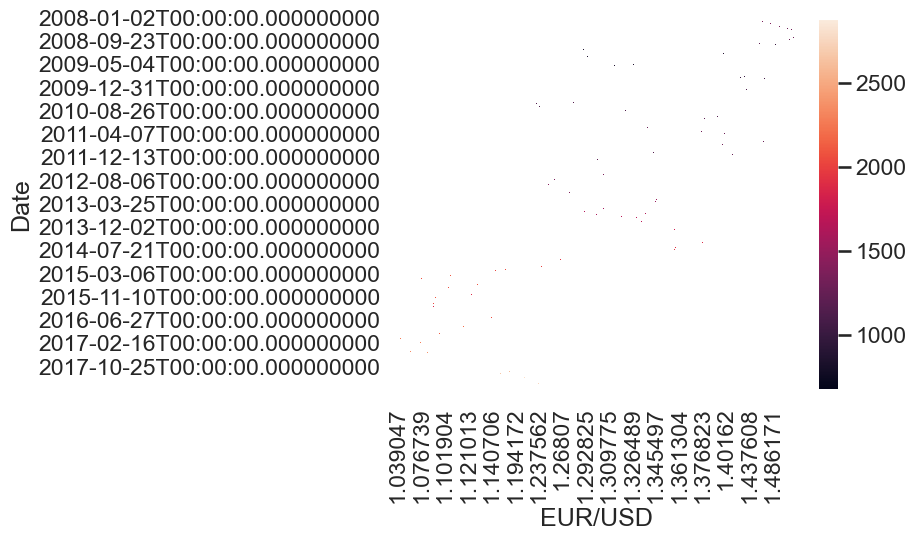

In [20]:
sns.heatmap(df.pivot_table(values = 'SPX',index='Date',columns='EUR/USD' ))

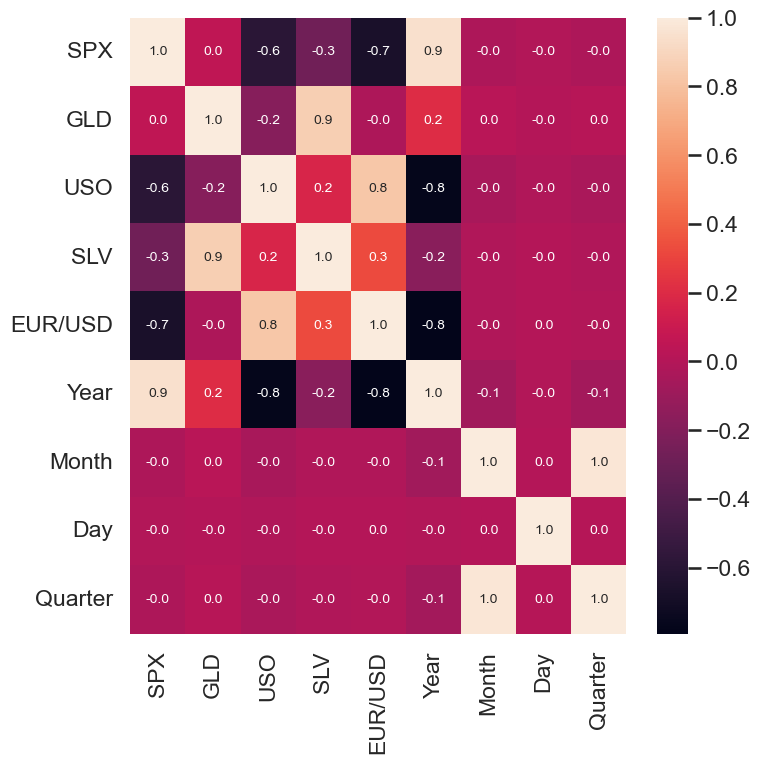

In [21]:
plt.figure(figsize =(8,8))
sns.heatmap(correlation ,cbar=True,fmt = '.1f',annot= True ,annot_kws={'size':10})
plt.show()

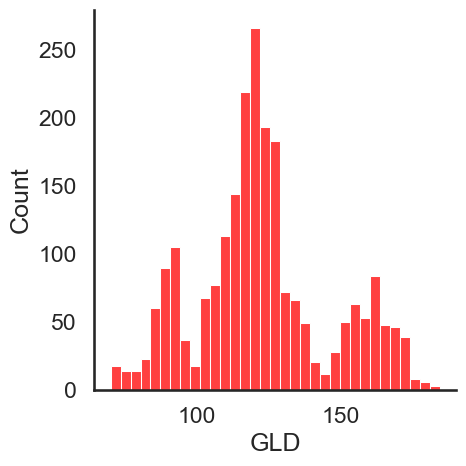

In [22]:
sns.displot(df['GLD'],color= 'red' )

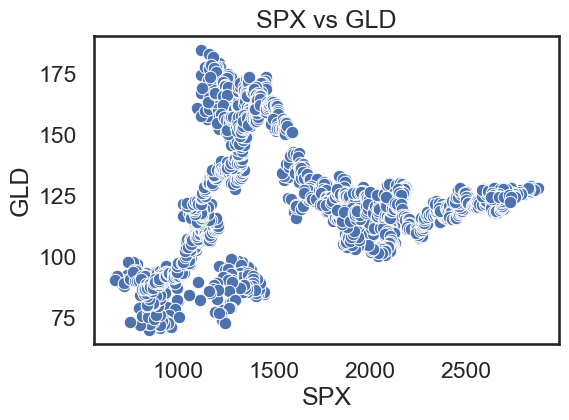

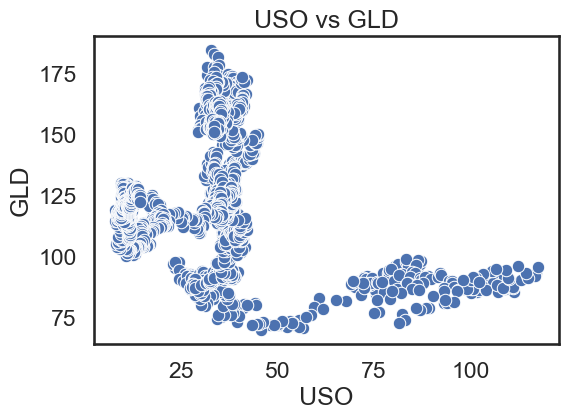

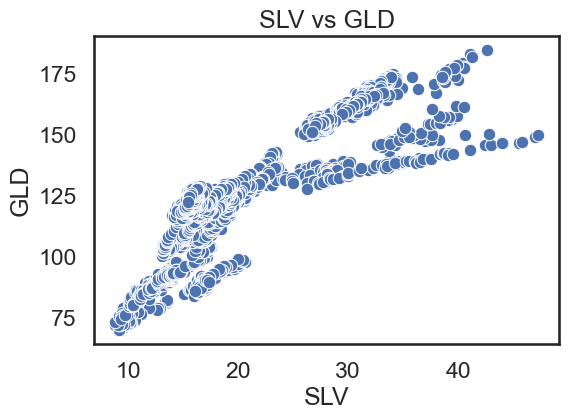

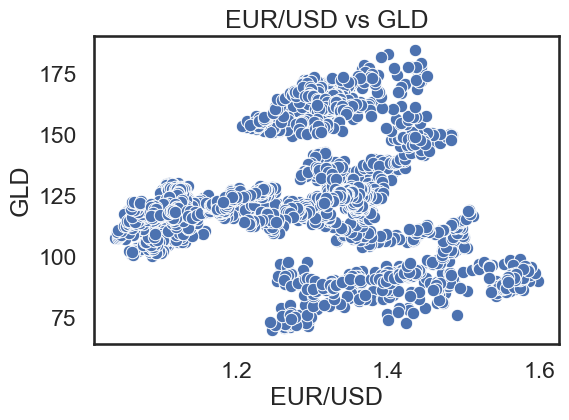

In [23]:
features = ['SPX','USO','SLV','EUR/USD']

for col in features:
    
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(
        x=df[col],
        y=df['GLD']
    )
    
    plt.title(f"{col} vs GLD")
    
    plt.show()

In [24]:
#Splitting the features AND targets 

In [25]:
X= df.drop(['Date','GLD'],axis = 1)
Y= df['GLD']

In [26]:
print(X)

              SPX        USO      SLV   EUR/USD  Year  Month  Day  Quarter
0     1447.160034  78.470001  15.1800  1.471692  2008      1    2        1
1     1447.160034  78.370003  15.2850  1.474491  2008      1    3        1
2     1411.630005  77.309998  15.1670  1.475492  2008      1    4        1
3     1416.180054  75.500000  15.0530  1.468299  2008      1    7        1
4     1390.189941  76.059998  15.5900  1.557099  2008      1    8        1
...           ...        ...      ...       ...   ...    ...  ...      ...
2285  2671.919922  14.060000  15.5100  1.186789  2018      5    8        2
2286  2697.790039  14.370000  15.5300  1.184722  2018      5    9        2
2287  2723.070068  14.410000  15.7400  1.191753  2018      5   10        2
2288  2730.129883  14.380000  15.5600  1.193118  2018      5   14        2
2289  2725.780029  14.405800  15.4542  1.182033  2018      5   16        2

[2290 rows x 8 columns]


In [27]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [28]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=.2,random_state=2)

In [29]:
X_train.head()

,SPX,USO,SLV,EUR/USD,Year,Month,Day,Quarter
476,1138.500000,39.790001,16.889999,1.361693,2010,3,8,1
1958,2202.939941,10.630000,15.800000,1.063886,2016,11,22,4
248,700.820007,24.480000,12.770000,1.256408,2009,3,2,1
2231,2656.000000,11.890000,15.570000,1.225280,2018,2,12,1
1325,1838.880005,33.040001,19.420000,1.366998,2014,1,14,1


In [30]:
lr = LinearRegression()

lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)

In [31]:
print(
    "Linear Regression R2:",
    r2_score(Y_test, lr_pred)
)

Linear Regression R2: 0.8951709746486723


In [32]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

In [33]:
results = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    pred = model.predict(X_test)

    r2 = r2_score(Y_test, pred)

    results.append(
        [name, r2]
    )

In [34]:
results_df = pd.DataFrame(
    results,
    columns=['Model','R2 Score']
)

results_df.sort_values(
    'R2 Score',
    ascending=False
)

,Model,R2 Score
1,Random Forest,0.994908
2,Gradient Boosting,0.989200
0,Linear Regression,0.895171


In [35]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}

In [36]:
grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(
    X_train,
    Y_train
)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [37]:
grid.best_params_

{'max_depth': 15, 'n_estimators': 300}

In [38]:
best_model = grid.best_estimator_

In [39]:
pred = best_model.predict(
    X_test
)

In [40]:
r2 = r2_score(Y_test,pred)

mae = mean_absolute_error(
    Y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        Y_test,
        pred
    )
)

print("R2:",r2)
print("MAE:",mae)
print("RMSE:",rmse)

R2: 0.9951522190230774
MAE: 0.9943435217806925
RMSE: 1.5990405150808402


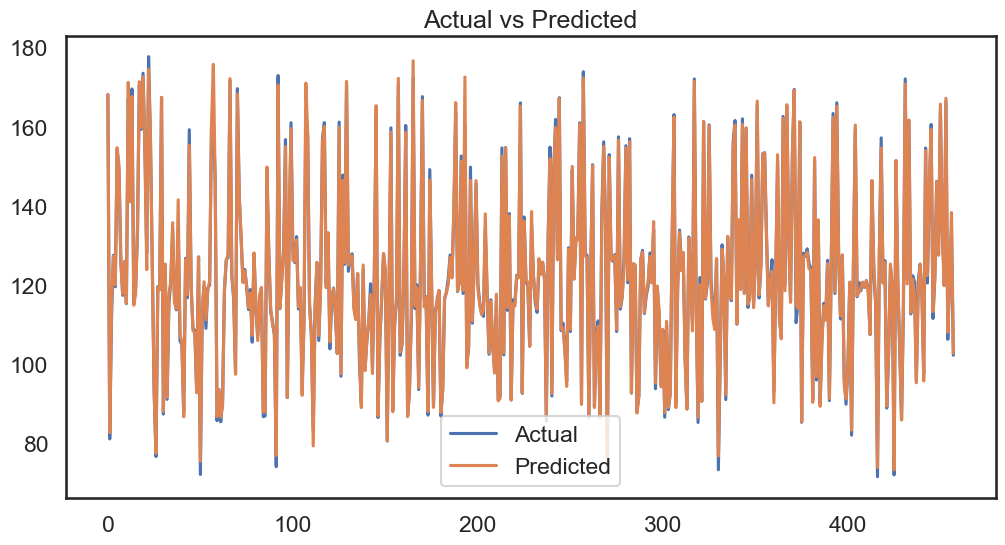

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    Y_test.values,
    label='Actual'
)

plt.plot(
    pred,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [42]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    best_model.feature_importances_

})

In [43]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

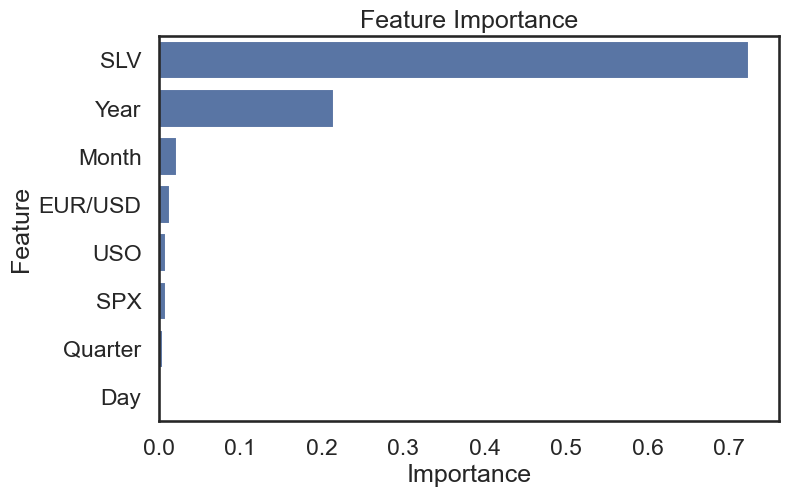

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

In [45]:
pickle.dump(
    best_model,
    open(
        'gold_price_model.pkl',
        'wb'
    )
)

print("Model Saved")

Model Saved


In [46]:
import os
print(os.getcwd())

C:\Users\KIIT\AIML PROJECTS\Gold Predicton


In [48]:
pickle.dump(best_model, open('gold_price_model.pkl', 'wb'))


In [49]:
print(X.columns.tolist())
print("Number of features:", X.shape[1])

['SPX', 'USO', 'SLV', 'EUR/USD', 'Year', 'Month', 'Day', 'Quarter']
Number of features: 8
